# End-to-End Insurance Risk Analytics & Predictive Modeling

## Task 1: Exploratory Data Analysis (EDA)

### Objective
The goal of this analysis is to explore historical insurance data and identify risk patterns that can support data-driven pricing strategies for AlphaCare Insurance Solutions (ACIS).

This notebook focuses on:
- Data understanding
- Data quality assessment
- Exploratory data analysis
- Risk analysis using Loss Ratio and Margin
- Geographic and temporal trends
- Business insights

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

# settings
pd.set_option('display.max_columns', None)

sns.set_style("whitegrid")

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
## Load Dataset

In [4]:
df = pd.read_csv("../data/insurance_data.csv")

print("Dataset loaded successfully")

Dataset loaded successfully


In [5]:
df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,PastClaims,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,1,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,4,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,1,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,0,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,4,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 10000
Columns: 21


In [7]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Province', 'VehicleType',
       'AnnualIncome', 'RiskScore', 'AnnualPremium', 'Deductible', 'NCD',
       'PastClaims', 'Claimed', 'ClaimAmount', 'TotalPremium', 'TotalClaims',
       'CoverType', 'AutoMake', 'VehicleModel', 'CustomValueEstimate',
       'ZipCode', 'TransactionDate'],
      dtype='object')

## Data Types and Structure

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           10000 non-null  object 
 1   Age                  10000 non-null  int64  
 2   Gender               10000 non-null  object 
 3   Province             10000 non-null  object 
 4   VehicleType          10000 non-null  object 
 5   AnnualIncome         10000 non-null  int64  
 6   RiskScore            10000 non-null  int64  
 7   AnnualPremium        10000 non-null  int64  
 8   Deductible           10000 non-null  int64  
 9   NCD                  10000 non-null  int64  
 10  PastClaims           10000 non-null  int64  
 11  Claimed              10000 non-null  bool   
 12  ClaimAmount          10000 non-null  float64
 13  TotalPremium         10000 non-null  int64  
 14  TotalClaims          10000 non-null  float64
 15  CoverType            10000 non-null  

## Descriptive Statistics

In [9]:
df.describe()

,Age,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,PastClaims,ClaimAmount,TotalPremium,TotalClaims,CustomValueEstimate,ZipCode
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,46.683500,79201.97390,58.140000,2488.127900,751.700000,20.935000,1.064200,1314.188500,2488.127900,1314.188500,35640.598700,23215.00050
std,16.717963,33039.93977,14.267486,735.674491,500.509401,14.549122,1.051945,3921.864903,735.674491,3921.864903,22353.988238,12848.33245
min,18.000000,17202.00000,15.000000,951.000000,250.000000,0.000000,0.000000,0.000000,951.000000,0.000000,5022.000000,10001.00000
25%,32.000000,56105.00000,48.000000,2028.000000,500.000000,10.000000,0.000000,0.000000,2028.000000,0.000000,21442.750000,10004.00000
50%,46.000000,72942.00000,57.000000,2307.000000,500.000000,20.000000,1.000000,0.000000,2307.000000,0.000000,28522.000000,20003.00000
75%,61.000000,95092.00000,67.000000,2676.000000,1000.000000,30.000000,2.000000,0.000000,2676.000000,0.000000,46721.000000,30004.00000
max,75.000000,376916.00000,95.000000,5105.000000,2000.000000,50.000000,5.000000,49623.000000,5105.000000,49623.000000,134914.000000,50005.00000


In [10]:
## Missing Value Analysis

In [11]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [12]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [13]:
## Feature Engineering

In [14]:
df['LossRatio'] = df['TotalClaims'] / df['TotalPremium']

In [15]:
df['Margin'] = df['TotalPremium'] - df['TotalClaims']

In [16]:
df.describe()

,Age,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,PastClaims,ClaimAmount,TotalPremium,TotalClaims,CustomValueEstimate,ZipCode,LossRatio,Margin
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,46.683500,79201.97390,58.140000,2488.127900,751.700000,20.935000,1.064200,1314.188500,2488.127900,1314.188500,35640.598700,23215.00050,0.442770,1173.939400
std,16.717963,33039.93977,14.267486,735.674491,500.509401,14.549122,1.051945,3921.864903,735.674491,3921.864903,22353.988238,12848.33245,1.252813,3742.979999
min,18.000000,17202.00000,15.000000,951.000000,250.000000,0.000000,0.000000,0.000000,951.000000,0.000000,5022.000000,10001.00000,0.000000,-44594.000000
25%,32.000000,56105.00000,48.000000,2028.000000,500.000000,10.000000,0.000000,0.000000,2028.000000,0.000000,21442.750000,10004.00000,0.000000,1812.000000
50%,46.000000,72942.00000,57.000000,2307.000000,500.000000,20.000000,1.000000,0.000000,2307.000000,0.000000,28522.000000,20003.00000,0.000000,2165.000000
75%,61.000000,95092.00000,67.000000,2676.000000,1000.000000,30.000000,2.000000,0.000000,2676.000000,0.000000,46721.000000,30004.00000,0.000000,2504.250000
max,75.000000,376916.00000,95.000000,5105.000000,2000.000000,50.000000,5.000000,49623.000000,5105.000000,49623.000000,134914.000000,50005.00000,15.895383,5079.000000


In [17]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

In [18]:
## Portfolio Risk Analysis

In [19]:
overall_loss_ratio = df['TotalClaims'].sum() / df['TotalPremium'].sum()

print("Overall Loss Ratio:", round(overall_loss_ratio, 2))

Overall Loss Ratio: 0.53


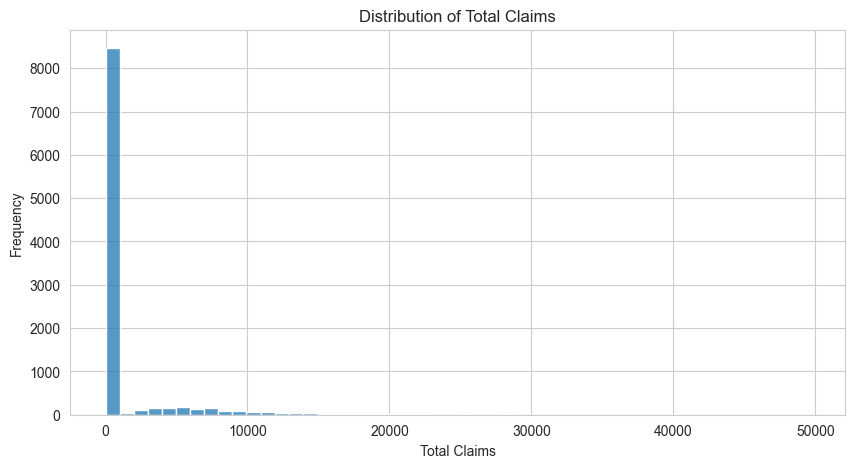

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(df['TotalClaims'], bins=50)

plt.title("Distribution of Total Claims")
plt.xlabel("Total Claims")
plt.ylabel("Frequency")

plt.show()

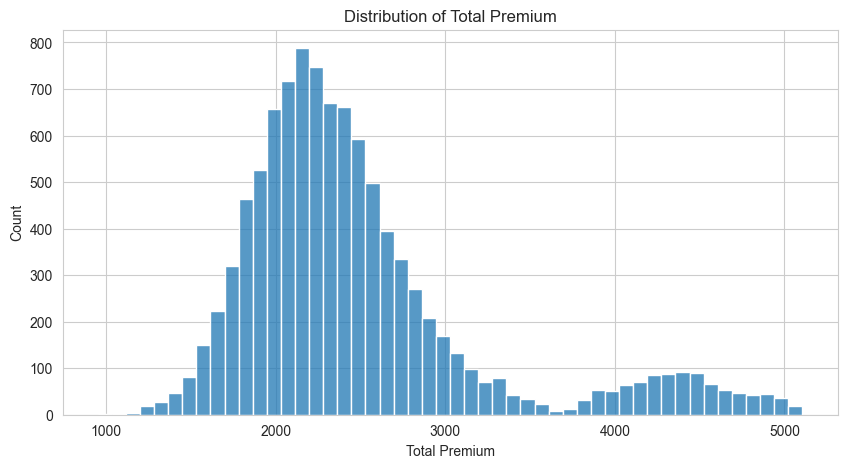

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(df['TotalPremium'], bins=50)

plt.title("Distribution of Total Premium")
plt.xlabel("Total Premium")

plt.show()

In [22]:
## Outlier Detection

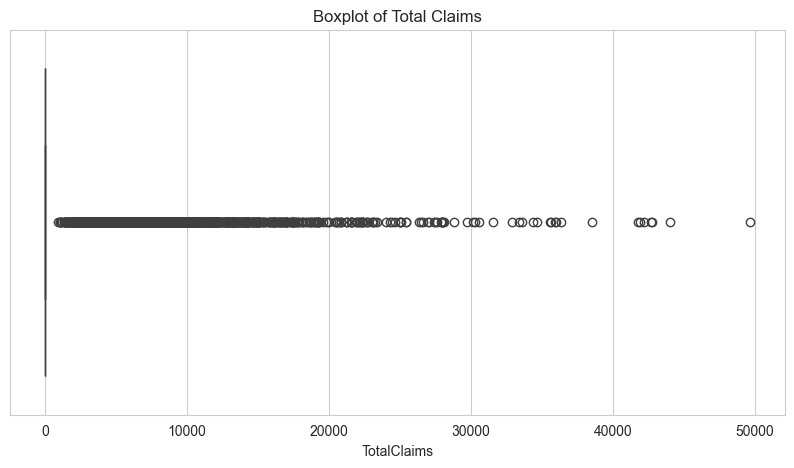

In [23]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['TotalClaims'])

plt.title("Boxplot of Total Claims")

plt.show()

## Geographic Risk Analysis

In [24]:
province_loss = df.groupby('Province')['LossRatio'].mean().sort_values(ascending=False)

province_loss

Province
Somali         0.523516
Oromia         0.452680
Tigray         0.438639
Addis Ababa    0.436347
Amhara         0.395941
Name: LossRatio, dtype: float64

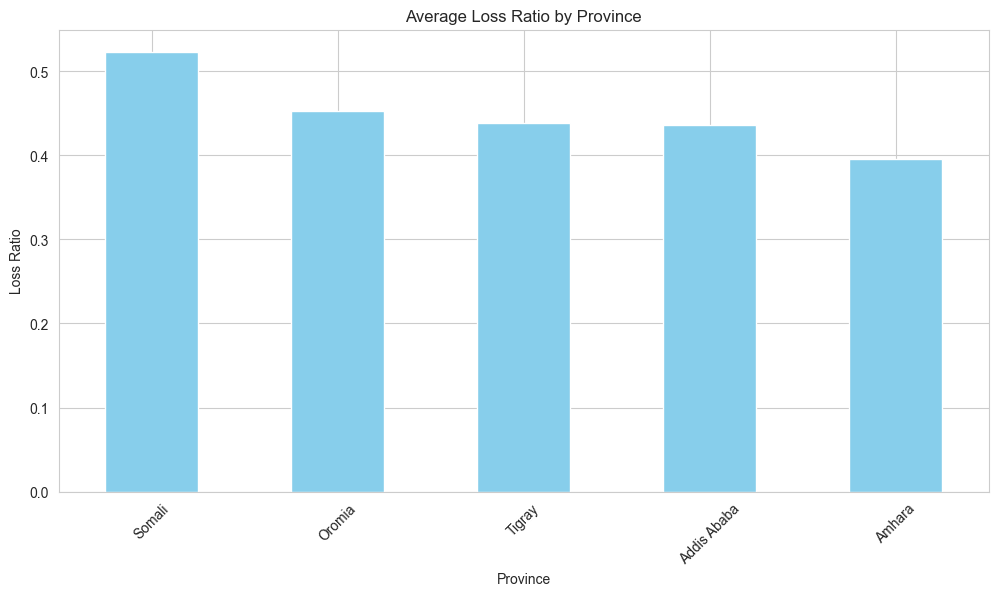

In [25]:
plt.figure(figsize=(12,6))

province_loss.plot(kind='bar', color='skyblue')

plt.title("Average Loss Ratio by Province")
plt.ylabel("Loss Ratio")
plt.xticks(rotation=45)

plt.show()

In [26]:
vehicle_claims = df.groupby('VehicleType')['TotalClaims'].mean().sort_values(ascending=False)

vehicle_claims

VehicleType
Luxury       3672.023663
SUV          1363.555000
Hatchback     935.282417
Sedan         896.236974
Name: TotalClaims, dtype: float64

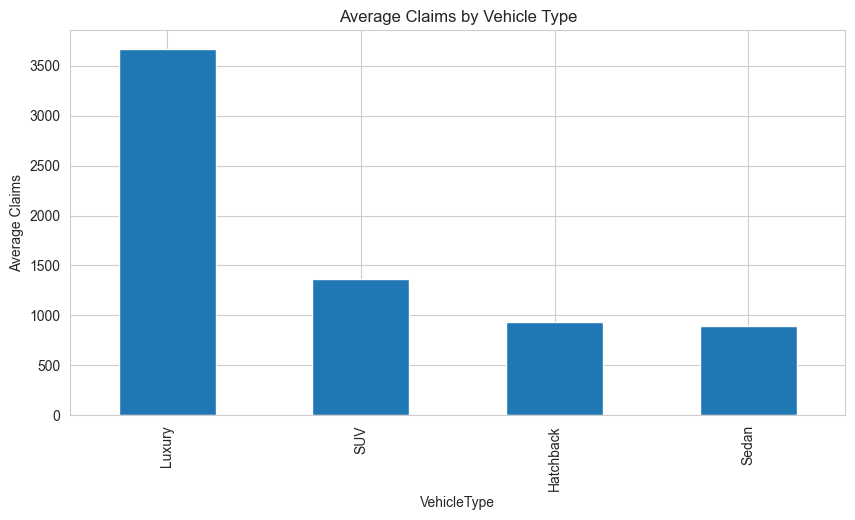

In [27]:
plt.figure(figsize=(10,5))

vehicle_claims.plot(kind='bar')

plt.title("Average Claims by Vehicle Type")
plt.ylabel("Average Claims")

plt.show()

In [28]:
gender_loss = df.groupby('Gender')['LossRatio'].mean()

gender_loss

Gender
Female    0.447351
Male      0.437929
Name: LossRatio, dtype: float64

In [29]:
## Temporal Trend Analysis

In [30]:
monthly_claims = df.groupby(df['TransactionDate'].dt.to_period('M'))['TotalClaims'].sum()

monthly_claims.index = monthly_claims.index.astype(str)

monthly_claims.head()

TransactionDate
2024-01    764324.0
2024-02    661946.0
2024-03    725682.0
2024-04    751881.0
2024-05    941073.0
Name: TotalClaims, dtype: float64

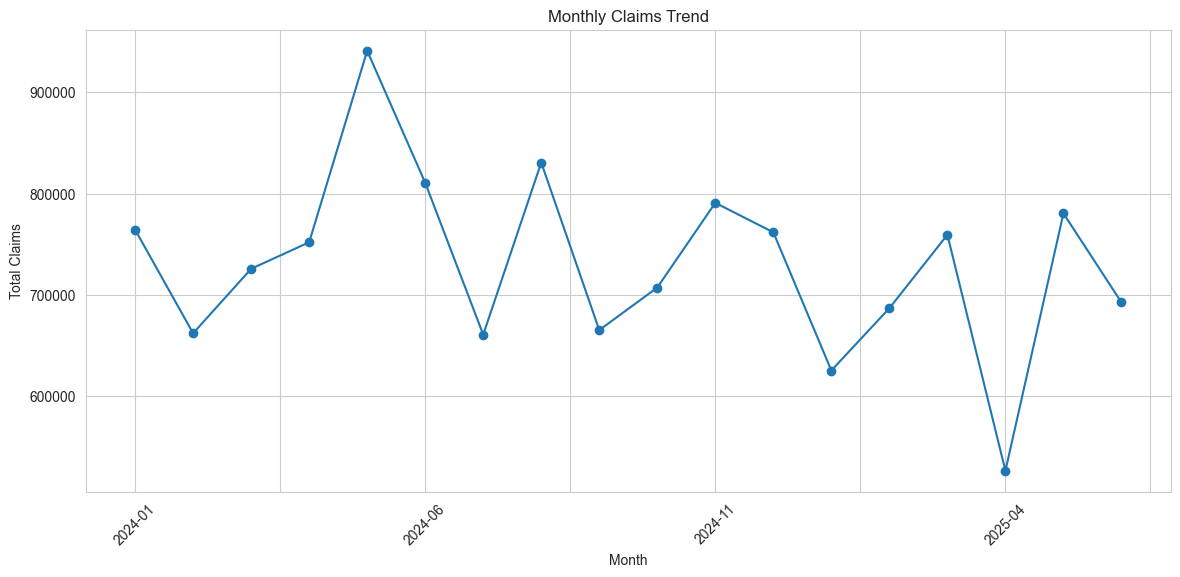

In [31]:
plt.figure(figsize=(14,6))

monthly_claims.plot(marker='o')

plt.title("Monthly Claims Trend")
plt.xlabel("Month")
plt.ylabel("Total Claims")

plt.xticks(rotation=45)

plt.show()

## Correlation Analysis

In [32]:
numeric_cols = df.select_dtypes(include=np.number)

corr = numeric_cols.corr()

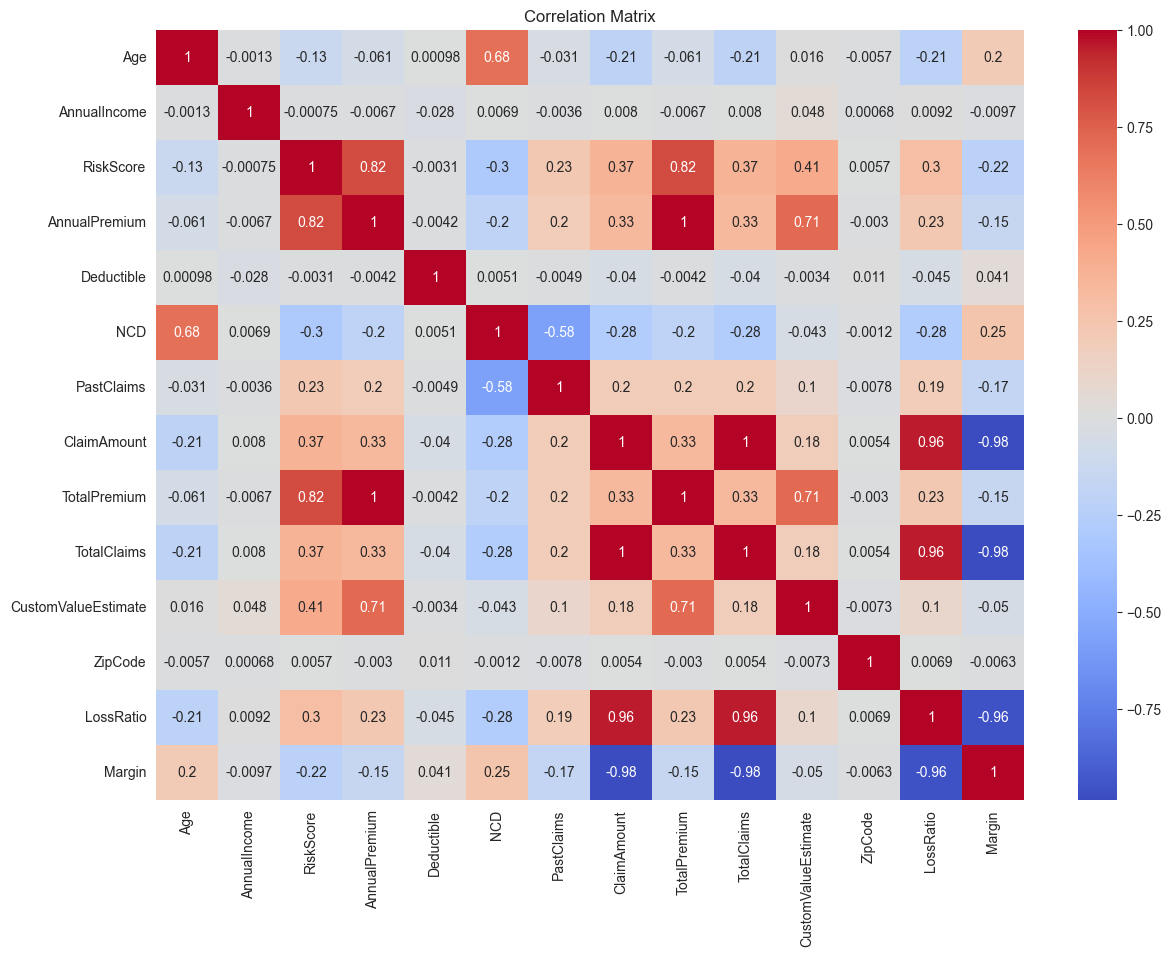

In [33]:
plt.figure(figsize=(14,10))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

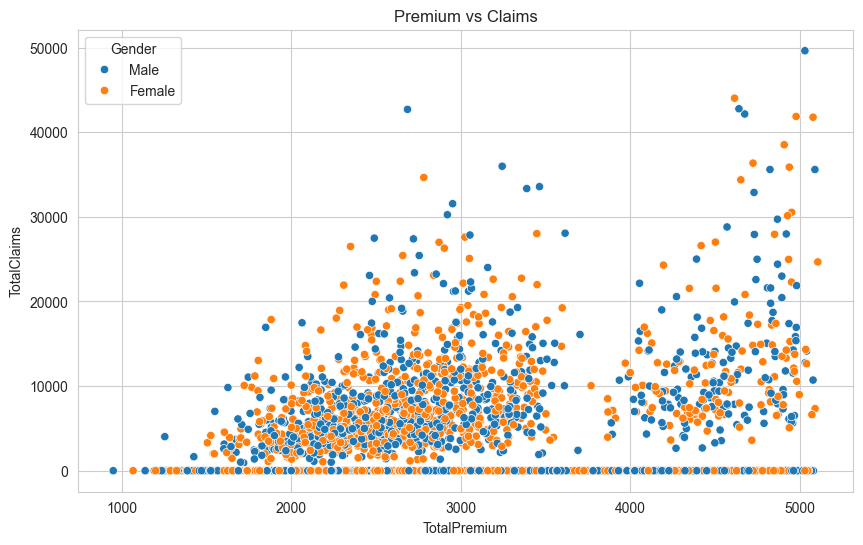

In [34]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='TotalPremium',
    y='TotalClaims',
    hue='Gender',
    data=df
)

plt.title("Premium vs Claims")

plt.show()

In [35]:
top_makes = df.groupby('AutoMake')['TotalClaims'].mean().sort_values(ascending=False)

top_makes.head(10)

AutoMake
Mercedes-Benz    3787.012618
BMW              3362.890855
Toyota           1372.520878
Suzuki           1122.025761
Hyundai          1042.739272
Lifan             918.103987
Name: TotalClaims, dtype: float64

In [36]:
import os

os.makedirs("../data", exist_ok=True)

df.to_csv("../data/cleaned_insurance_data.csv", index=False)

print("Cleaned dataset saved!")

Cleaned dataset saved!
